In [1]:
import pandas as pd
df = pd.read_csv("/content/retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
#Understanding the data
df.shape

(1000, 9)

In [3]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [5]:
#Data Cleaning
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [12]:
#Calculate Total Sales by Categories
category_sales = df.groupby("Product Category")["Total Amount"].sum()
category_sales

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


In [15]:
category_sales.max()

156905

In [16]:
category_sales.idxmax()

'Electronics'

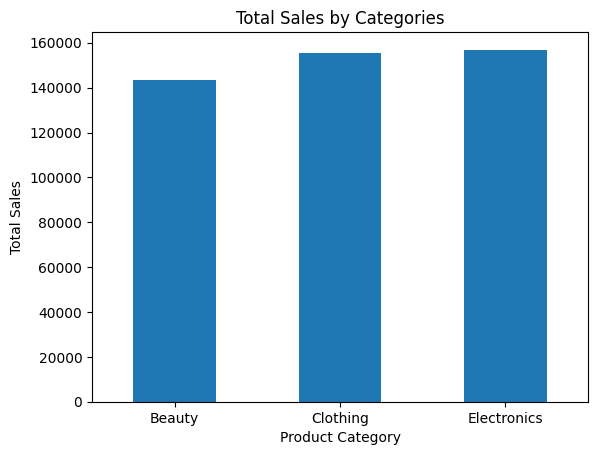

In [18]:
import matplotlib.pyplot as plt
category_sales.plot(kind="bar")

plt.title("Total Sales by Categories")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [20]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("Month")["Total Amount"].sum()
monthly_sales

,Total Amount
Month,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


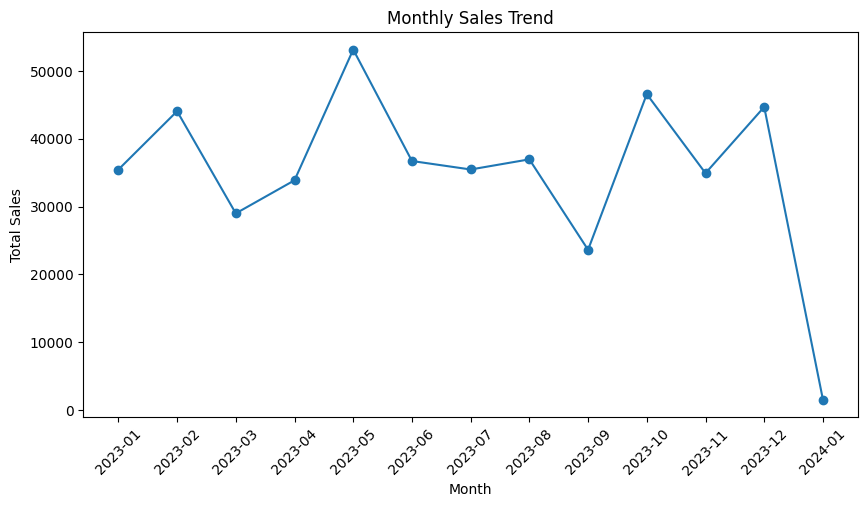

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

In [22]:
#top 10 customers by total spending.
customer_sales = df.groupby("Customer ID")["Total Amount"].sum()
customer_sales.sort_values(ascending=False).head(10)

,Total Amount
Customer ID,
CUST015,2000
CUST412,2000
CUST970,2000
CUST547,2000
CUST281,2000
CUST416,2000
CUST420,2000
CUST927,2000
CUST447,2000


In [23]:
top_customer = customer_sales.idxmax()
top_customer

'CUST015'

In [25]:
#Gender wise Sales
gender_sales = df.groupby("Gender")["Total Amount"].sum()
gender_sales

,Total Amount
Gender,
Female,232840
Male,223160


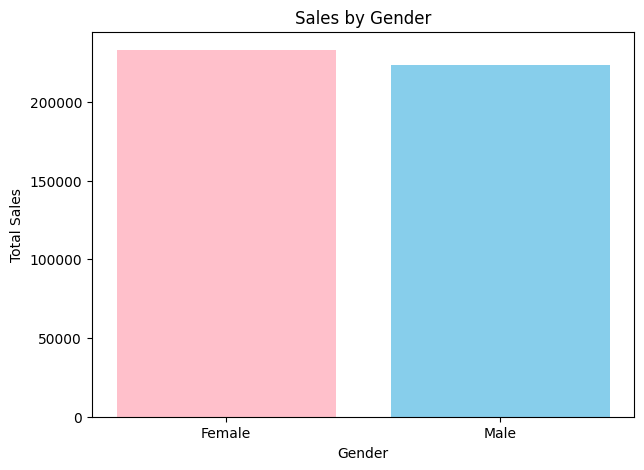

In [29]:
plt.figure(figsize=(7, 5))

plt.bar(gender_sales.index, gender_sales.values,color=["pink","skyblue"])

plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.show()

In [30]:
#Age Group Analysis
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["Under 18", "18–30", "31–45", "46–60", "60+"]
)

age_group_sales = df.groupby("Age Group", observed=False)["Total Amount"].sum()

age_group_sales

,Total Amount
Age Group,
Under 18,11215
18–30,121730
31–45,141955
46–60,147875
60+,33225


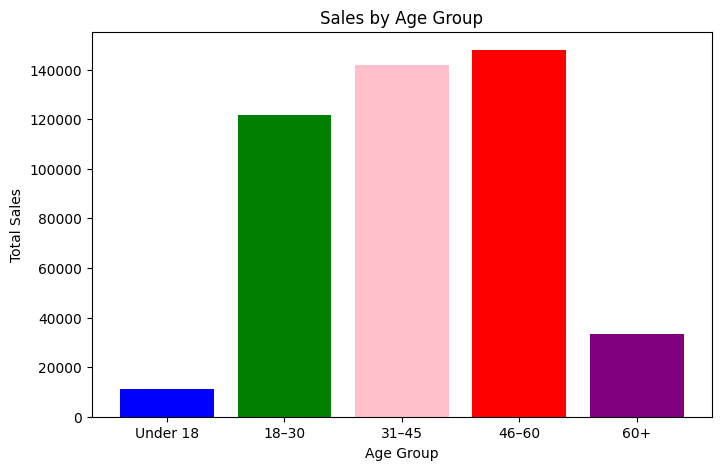

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(age_group_sales.index.astype(str), age_group_sales.values,color=["blue","green","pink","red","purple"])

plt.title("Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")

plt.show()

In [34]:
print("KEY BUSINESS INSIGHTS")
print("---------------------")

print("1. Best-selling product category:",
      category_sales.idxmax())

print("2. Highest-spending customer:",
      customer_sales.idxmax())

print("3. Highest customer spending:",
      customer_sales.max())

print("4. Best-performing gender:",
      gender_sales.idxmax())

print("5. Best-performing age group:",
      age_group_sales.idxmax())

print("6. Highest monthly sales month:",
      monthly_sales.idxmax())

print("7. Highest monthly sales amount:",
      monthly_sales.max())

KEY BUSINESS INSIGHTS
---------------------
1. Best-selling product category: Electronics
2. Highest-spending customer: CUST015
3. Highest customer spending: 2000
4. Best-performing gender: Female
5. Best-performing age group: 46–60
6. Highest monthly sales month: 2023-05
7. Highest monthly sales amount: 53150


## Key Insights

- The best-performing product category generated the highest total sales.
- Customer analysis helped identify the highest-spending customer.
- Gender-wise analysis showed which gender contributed more to total sales.
- Age-group analysis identified the most valuable customer age group.
- Monthly sales analysis helped identify the month with the highest sales.
- These insights can help businesses improve marketing, inventory planning, and customer targeting.

## Conclusion

This project analyzed retail sales data using Python, Pandas, and Matplotlib. The analysis explored product category performance, monthly sales trends, customer spending, gender-wise sales, and age-group sales. The findings can support better business decisions related to marketing, inventory management, and customer segmentation.

# Final Project Summary

## Project Title
Retail Sales & Customer Insights

## Objective
Analyze retail sales data to understand sales trends, product performance, customer spending, gender-wise sales, and age-group behavior.

## Tools Used
- Python
- Pandas
- Matplotlib
- Google Colab

## Analysis Performed
1. Product category sales analysis
2. Monthly sales trend analysis
3. Gender-wise sales analysis
4. Age-group sales analysis
5. Top customer spending analysis
6. Key business insights

## Business Value
The analysis can help businesses improve:
- Marketing campaigns
- Inventory planning
- Customer targeting
- Product promotion
- Sales forecasting decisions

## Conclusion
This project demonstrates the use of Python, Pandas, and Matplotlib to analyze retail data and convert raw data into useful business insights.